# Mahendrawada 2025 vs Harbison 2004 Correlation Analysis Tutorial

This tutorial demonstrates the steps to preprocess data and perform comprehensive correlation analysis between the Mahendrawada and Harbison datasets, while focusing on target distribution.

## Overview

Correlation analysis evalute the relationship between the two datasets by ensuring data integrity through filtering and examining correlations across p-values and effects, both globally and at the individual regulator level.

### Datasets Used
- **Binding data**: Mahendrawada 2025 (binding), Harbison 2004 (binding)

### Analysis Strategy
1. Load and filter out missing rows from both Mahendrawada and Harbison datasets
2. Plot the distribution of the number of common targets over regulators
3. Perform comprehensive correlation analysis across five key dimensions:
   - overall p-value correlation
   - overall effect correlation
   - p-value correlation grouped by regulator
   - effect correlation grouped by regulator
   - p-value vs. effect correlation grouped by regulator

# Initialize API and Check Available Configurations

In [74]:
from tfbpapi.HfQueryAPI import HfQueryAPI
import pandas as pd

# Initialize the API client
mahendrawada_api = HfQueryAPI(repo_id="BrentLab/mahendrawada_2025", repo_type="dataset")

print(f"Initialized HfQueryAPI for {mahendrawada_api.repo_id}")
print(f"Repository type: {mahendrawada_api.repo_type}")
print(f"Available configurations: {[c.config_name for c in mahendrawada_api.configs]}")

Initialized HfQueryAPI for BrentLab/mahendrawada_2025
Repository type: dataset
Available configurations: ['genomic_features', 'mahendrawada_2025_metadata', 'chec_seq_genome_map', 'mahendrawada_chec_seq', 'reprocessed_chec_seq', 'reprocessed_diffcontrol_5prime', 'rna_seq']


In [75]:
# Initialize the API client
harbison_api = HfQueryAPI(repo_id="BrentLab/harbison_2004", repo_type="dataset")

print(f"Initialized HfQueryAPI for {harbison_api.repo_id}")
print(f"Repository type: {harbison_api.repo_type}")
print(f"Available configurations: {[c.config_name for c in harbison_api.configs]}")

Initialized HfQueryAPI for BrentLab/harbison_2004
Repository type: dataset
Available configurations: ['harbison_2004']


# Retrieve metadata for mahendrawada_2025 and check for duplicate values.

In [76]:
mahendrawada_metadata = mahendrawada_api.get_metadata("reprocessed_diffcontrol_5prime")

In [77]:
print(mahendrawada_metadata)

    control_source  condition regulator_locus_tag  count
0            h2021   standard             YNL027W   6708
1            m2025   standard             YDL080C   6708
2            h2021   standard             YLR223C   6708
3            h2021  raffinose             YPL248C   6708
4            h2021   standard             YNL199C   6708
..             ...        ...                 ...    ...
389          h2021   standard             YBL103C   6708
390          m2025   standard             YPL202C   6708
391          m2025   standard             YOR038C   6708
392          m2025   standard             YER111C   6708
393          h2021   standard             YNL216W   6708

[394 rows x 4 columns]


In [78]:
mahendrawada_metadata.groupby(["control_source", "condition"]).size()

control_source  condition
h2021           30             2
                37             2
                SM             1
                WT             1
                WT_SM          1
                admut          1
                admut_SM       1
                cAD            1
                cAD_SM         1
                dbdmut         1
                dbdmut_SM      1
                galactose      1
                nAD            1
                nAD_SM         1
                ncAD           1
                ncAD_SM        1
                raffinose      1
                standard     178
m2025           30             2
                37             2
                SM             1
                WT             1
                WT_SM          1
                admut          1
                admut_SM       1
                cAD            1
                cAD_SM         1
                dbdmut         1
                dbdmut_SM      1
                g

In [79]:
# check h2021 - standard
h2021_standard = mahendrawada_metadata[(mahendrawada_metadata["control_source"] == "h2021") & (mahendrawada_metadata["condition"] == "standard")]
h2021_duplicates = h2021_standard[h2021_standard.duplicated(subset=["regulator_locus_tag"], keep=False)]
if not h2021_duplicates.empty:
    print("There are duplicate regulator_locus_tags under control_source=h2021, condition=standard:")
    print(h2021_duplicates[["regulator_locus_tag"]])
else:
    print("Under control_source=h2021, condition=standard, regulator_locus_tag has no duplicate values.")

# check m2025 - standard
m2025_standard = mahendrawada_metadata[(mahendrawada_metadata["control_source"] == "m2025") & (mahendrawada_metadata["condition"] == "standard")]
m2025_duplicates = m2025_standard[m2025_standard.duplicated(subset=["regulator_locus_tag"], keep=False)]
if not m2025_duplicates.empty:
    print("There are duplicate regulator_locus_tags under control_source=m2025, condition=standard:")
    print(m2025_duplicates[["regulator_locus_tag"]])
else:
    print("Under control_source=m2025, condition=standard, regulator_locus_tag has no duplicate values.")

Under control_source=h2021, condition=standard, regulator_locus_tag has no duplicate values.
Under control_source=m2025, condition=standard, regulator_locus_tag has no duplicate values.


# Retrieve metadata for harbison_2004 and check for duplicate values.

In [80]:
harbison__metadata = harbison_api.get_metadata("harbison_2004")

In [81]:
print(harbison__metadata)

    regulator_locus_tag regulator_symbol condition  count
0               YER040W             GLN3       YPD   6226
1               YPL202C             AFT2       YPD   6226
2               YDR043C             NRG1    H2O2Hi   6226
3               YOR028C             CIN5    H2O2Lo   6226
4               YNL068C             FKH2    H2O2Lo   6226
..                  ...              ...       ...    ...
347             YML076C             WAR1       YPD   6226
348             YGL254W             FZF1       YPD   6226
349             YMR070W             MOT3    H2O2Lo   6226
350             YML007W             YAP1       YPD   6226
351             YOR344C             TYE7       YPD   6226

[352 rows x 4 columns]


In [82]:
harbison__metadata.groupby(["condition"]).size()

condition
Acid        2
Alpha       5
BUT14       8
BUT90       4
GAL         4
H2O2Hi     39
H2O2Lo     28
HEAT        6
Pi-         2
RAFF        1
RAPA       14
SM         34
Thi-        1
YPD       204
dtype: int64

In [83]:
# When the check condition is YPD, check if the regulator_locus_tag is duplicated.
harbison_ypd = harbison__metadata[harbison__metadata["condition"] == "YPD"]
harbison_ypd_duplicates = harbison_ypd[harbison_ypd.duplicated(subset=["regulator_locus_tag"], keep=False)]
if not harbison_ypd_duplicates.empty:
    print("There are duplicate regulator_locus_tags under condition=YPD:")
    print(harbison_ypd_duplicates[["regulator_locus_tag"]])
else:
    print("Under condition=YPD, regulator_locus_tag has no duplicate values.")


Under condition=YPD, regulator_locus_tag has no duplicate values.


# Check how many intersections there are between h2021 and m2025 of mahendrawada_2025 and harbison_2004.

In [84]:
# Retrieve the regulator_locus_tag from harbison_ypd and remove duplicates.
harbison_ypd_tags = set(harbison_ypd["regulator_locus_tag"].unique())

# Retrieve the regulator_locus_tag with control_source=h2021 and condition=standard from the metadata and remove duplicates.
h2021_standard_tags = set(mahendrawada_metadata[(mahendrawada_metadata["control_source"] == "h2021") & (mahendrawada_metadata["condition"] == "standard")]["regulator_locus_tag"].unique())

# Get the intersection
intersect_h2021 = harbison_ypd_tags & h2021_standard_tags

# Output the intersection elements and number
print("The intersection of harbison_ypd and the regulator_locus_tag of metadata[control_source='h2021', condition='standard']:")
print(intersect_h2021)
print(f"There are a total of {len(intersect_h2021)} intersection elements.")

# Retrieve the regulator_locus_tag with control_source=m2025 and condition=standard from the metadata and remove duplicates.
m2025_standard_tags = set(mahendrawada_metadata[(mahendrawada_metadata["control_source"] == "m2025") & (mahendrawada_metadata["condition"] == "standard")]["regulator_locus_tag"].unique())

# Get the intersection
intersect_m2025 = harbison_ypd_tags & m2025_standard_tags

# Output the intersection elements and number
print("The intersection of harbison_ypd and the regulator_locus_tag of metadata[control_source='m2025', condition='standard']:")
print(intersect_m2025)
print(f"There are a total of {len(intersect_m2025)} intersection elements.")


The intersection of harbison_ypd and the regulator_locus_tag of metadata[control_source='h2021', condition='standard']:
{'YMR164C', 'YIR023W', 'YGL131C', 'YDR463W', 'YBR239C', 'YDR421W', 'YML051W', 'YJL206C', 'YKR064W', 'YNL199C', 'YHR006W', 'YKR099W', 'YNL216W', 'YOR380W', 'YNL103W', 'YPL202C', 'YMR016C', 'YIL131C', 'YML076C', 'YEL009C', 'YDR213W', 'YBL005W', 'YGL209W', 'YBL103C', 'YOR162C', 'YOR229W', 'YBR049C', 'YKL015W', 'YNL167C', 'YER045C', 'YOR363C', 'YHR178W', 'YGL254W', 'YOR113W', 'YLR451W', 'YOL108C', 'YDR207C', 'YOR358W', 'YDR216W', 'YDL056W', 'YIR018W', 'YIL036W', 'YGL237C', 'YGL162W', 'YFR034C', 'YPL248C', 'YPL038W', 'YGL073W', 'YLR182W', 'YOL089C', 'YML007W', 'YGR249W', 'YER130C', 'YLR098C', 'YMR021C', 'YKL222C', 'YLR403W', 'YER169W', 'YML081W', 'YMR070W', 'YPL049C', 'YDR043C', 'YGL013C', 'YPR104C', 'YPL177C', 'YKL062W', 'YJR140C', 'YOR140W', 'YKL109W', 'YER111C', 'YFL021W', 'YLR014C', 'YPR022C', 'YDR253C', 'YMR037C', 'YNL068C', 'YHR206W', 'YJL110C', 'YBR182C', 'YDR451C',

# Set filters and use the query function to retrieve data.

In [85]:
# Set filters
harbison_api.set_filter("harbison_2004", condition="YPD")
mahendrawada_api.set_filter("reprocessed_diffcontrol_5prime", condition="standard")

In [86]:
harbison_YPD = harbison_api.query("SELECT * FROM harbison_2004 WHERE condition='YPD'", "harbison_2004")

h2021_standard = mahendrawada_api.query(
    "SELECT * FROM reprocessed_diffcontrol_5prime WHERE control_source='h2021'",
    "reprocessed_diffcontrol_5prime")
    
m2025_standard = mahendrawada_api.query(
    "SELECT * FROM reprocessed_diffcontrol_5prime WHERE control_source='m2025'",
    "reprocessed_diffcontrol_5prime")

Check if the effect has negative values.

In [87]:
harbison_YPD.effect.min()

np.float64(0.014319528)

# Check both datasets and remove missing values

In [88]:
# Check if harbison_YPD has missing values ​​(NaN), and count the number and proportion.
import numpy as np

# Count the number of missing values ​​in each column.
nan_counts = harbison_YPD.isna().sum()
print("Number of missing values ​​in each column:\n", nan_counts)

# Count the proportion of missing values ​​in each column.
nan_ratios = harbison_YPD.isna().mean()
print("Percentage of missing values ​​in each column:\n", nan_ratios)

# Count the total number of missing values ​​and the overall proportion.
total_nan = harbison_YPD.isna().sum().sum()
total_elements = np.prod(harbison_YPD.shape)
print(f"Total number of missing values: {total_nan}")
print(f"Overall missing value ratio: {total_nan/total_elements:.4%}")

Number of missing values ​​in each column:
 regulator_locus_tag        0
regulator_symbol           0
target_locus_tag           0
target_symbol              0
condition                  0
effect                 31732
pvalue                 31682
dtype: int64
Percentage of missing values ​​in each column:
 regulator_locus_tag    0.000000
regulator_symbol       0.000000
target_locus_tag       0.000000
target_symbol          0.000000
condition              0.000000
effect                 0.024984
pvalue                 0.024944
dtype: float64
Total number of missing values: 63414
Overall missing value ratio: 0.7133%


In [89]:
# Remove rows with missing values from harbison_YPD and store the result in a new variable (without changing harbison_YPD)
harbison_YPD_nonan = harbison_YPD.dropna()

In [90]:
# Check if there are any NaN values in m2025_standard_masked and h2021_standard_masked
print("NaN values in m2025_standard:\n", m2025_standard.isna().sum())
print("NaN values in h2021_standard:\n", h2021_standard.isna().sum())
# calculate the data missing rate (NaN ratio)
nan_ratio_m2025 = m2025_standard.isna().mean()
nan_ratio_h2021 = h2021_standard.isna().mean()
print("m2025_standard missing rate:\n", nan_ratio_m2025)
print("h2021_standard missing rate:\n", nan_ratio_h2021)

NaN values in m2025_standard:
 control_source                          0
condition                               0
regulator_locus_tag                     0
target_locus_tag                        0
chr                                     0
start                                   0
end                                     0
strand                                  0
input_vs_target_log2_fold_change    24429
input_vs_target_p_value                 0
input_vs_target_adj_p_value             0
dtype: int64
NaN values in h2021_standard:
 control_source                          0
condition                               0
regulator_locus_tag                     0
target_locus_tag                        0
chr                                     0
start                                   0
end                                     0
strand                                  0
input_vs_target_log2_fold_change    21443
input_vs_target_p_value                 0
input_vs_target_adj_p_value             0
d

In [91]:
# Remove missing values from m2025_standard and h2021_standard, and store in new variables
m2025_standard_nonan = m2025_standard.dropna()
h2021_standard_nonan = h2021_standard.dropna()

# Plot the distribution of the number of common targets over regulators

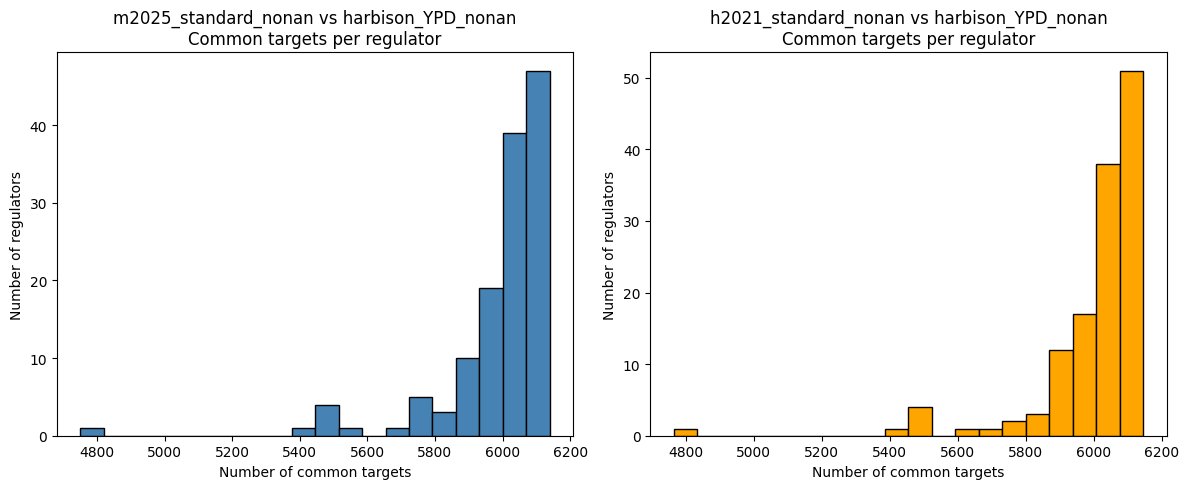

In [92]:
import matplotlib.pyplot as plt

# Calculate the number of common targets for each regulator (regulator_locus_tag) in both datasets

def get_common_targets_count(df1, df2):
    # Group by regulator and store targets as sets
    targets1 = df1.groupby("regulator_locus_tag")["target_locus_tag"].apply(set)
    targets2 = df2.groupby("regulator_locus_tag")["target_locus_tag"].apply(set)
    # Find regulators present in both datasets
    common_regulators = set(targets1.index) & set(targets2.index)
    # Calculate the number of common targets for each regulator
    common_target_counts = []
    for reg in common_regulators:
        common_targets = targets1[reg] & targets2[reg]
        common_target_counts.append(len(common_targets))
    return common_target_counts

# m2025_standard_nonan vs harbison_YPD_nonan
common_target_counts_m2025 = get_common_targets_count(m2025_standard_nonan, harbison_YPD_nonan)

# h2021_standard_nonan vs harbison_YPD_nonan
common_target_counts_h2021 = get_common_targets_count(h2021_standard_nonan, harbison_YPD_nonan)

# Plot the histograms to show the distribution of the number of common targets
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(common_target_counts_m2025, bins=20, color='steelblue', edgecolor='k')
plt.title("m2025_standard_nonan vs harbison_YPD_nonan\nCommon targets per regulator")
plt.xlabel("Number of common targets")
plt.ylabel("Number of regulators")

plt.subplot(1,2,2)
plt.hist(common_target_counts_h2021, bins=20, color='orange', edgecolor='k')
plt.title("h2021_standard_nonan vs harbison_YPD_nonan\nCommon targets per regulator")
plt.xlabel("Number of common targets")
plt.ylabel("Number of regulators")

plt.tight_layout()
plt.show()


For the row with input_vs_target_log2_fold_change, we set input_vs_target_log2_fold_change to 0 and input_vs_target_adj_p_value to 1.

In [93]:
# harbison_h2021
mask_h2021 = h2021_standard_nonan["input_vs_target_log2_fold_change"] < 0
h2021_standard_masked = h2021_standard_nonan.copy()
h2021_standard_masked.loc[mask_h2021, "input_vs_target_adj_p_value"] = 1
h2021_standard_masked.loc[mask_h2021, "input_vs_target_log2_fold_change"] = 0

# harbison_m2025
mask_m2025 = m2025_standard_nonan["input_vs_target_log2_fold_change"] < 0
m2025_standard_masked = m2025_standard_nonan.copy()
m2025_standard_masked.loc[mask_m2025, "input_vs_target_adj_p_value"] = 1
m2025_standard_masked.loc[mask_m2025, "input_vs_target_log2_fold_change"] = 0

In [94]:
# Join harbison_YPD and h2021_standard based on the regulator_locus_tag field.
harbison_h2021_joined = harbison_YPD_nonan.merge(
    h2021_standard_masked,
    on=["regulator_locus_tag", "target_locus_tag"],
    suffixes=('_harbison', '_h2021')
)

# Join harbison_YPD and m2025_standard based on the regulator_locus_tag field.
harbison_m2025_joined = harbison_YPD_nonan.merge(
    m2025_standard_masked,
    on=["regulator_locus_tag", "target_locus_tag"],
    suffixes=('_harbison', '_m2025')
)


In [95]:
harbison_m2025_joined

,regulator_locus_tag,regulator_symbol,target_locus_tag,target_symbol,condition_harbison,effect,pvalue,control_source,condition_m2025,chr,start,end,strand,input_vs_target_log2_fold_change,input_vs_target_p_value,input_vs_target_adj_p_value
0,YKL112W,ABF1,YAL001C,TFC3,YPD,0.860114,0.655859,m2025,standard,chrI,151169.0,151868.0,-,0.000000,2.155015e-06,1.000000
1,YER045C,ACA1,YAL001C,TFC3,YPD,1.020562,0.462418,m2025,standard,chrI,151169.0,151868.0,-,0.000000,8.366915e-02,1.000000
2,YDR216W,ADR1,YAL001C,TFC3,YPD,1.371479,0.062668,m2025,standard,chrI,151169.0,151868.0,-,0.000000,1.737008e-04,1.000000
3,YPL202C,AFT2,YAL001C,TFC3,YPD,1.028580,0.470920,m2025,standard,chrI,151169.0,151868.0,-,0.000000,4.591905e-01,1.000000
4,YMR042W,ARG80,YAL001C,TFC3,YPD,1.212880,0.185439,m2025,standard,chrI,151169.0,151868.0,-,0.000000,2.036065e-08,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787491,YLR403W,SFP1,YPR204W,YPR204W,YPD,1.000119,0.500925,m2025,standard,chrXVI,944185.0,944599.0,+,0.000000,8.691729e-01,1.000000
787492,YNL167C,SKO1,YPR204W,YPR204W,YPD,1.190853,0.285963,m2025,standard,chrXVI,944185.0,944599.0,+,0.000000,8.800214e-01,1.000000
787493,YGL131C,SNT2,YPR204W,YPR204W,YPD,0.876957,0.755442,m2025,standard,chrXVI,944185.0,944599.0,+,0.217182,9.499403e-01,0.977196
787494,YDR207C,UME6,YPR204W,YPR204W,YPD,1.285187,0.228696,m2025,standard,chrXVI,944185.0,944599.0,+,0.000000,5.004537e-01,1.000000


# Overall Analysis：P-value ranking correlation analysis

In [96]:
from scipy.stats import spearmanr

# Calculate the Spearman rank correlation between harbison_2004 and mahendrawada_2025 (h2021 joined regulators)
df_h2021 = harbison_h2021_joined[["pvalue", "input_vs_target_adj_p_value"]].dropna()
spearman_corr_h2021, spearman_p_h2021 = spearmanr(df_h2021["pvalue"], df_h2021["input_vs_target_adj_p_value"])

print("Spearman rank correlation of regulators for harbison_2004 vs mahendrawada_2025 (h2021): {:.3f}, p-value: {:.2g}".format(spearman_corr_h2021, spearman_p_h2021))

# Calculate the Spearman rank correlation between harbison_2004 and mahendrawada_2025 (m2025 joined regulators)
df_m2025 = harbison_m2025_joined[["pvalue", "input_vs_target_adj_p_value"]].dropna()
spearman_corr_m2025, spearman_p_m2025 = spearmanr(df_m2025["pvalue"], df_m2025["input_vs_target_adj_p_value"])

print("Spearman rank correlation of regulators for harbison_2004 vs mahendrawada_2025 (m2025): {:.3f}, p-value: {:.2g}".format(spearman_corr_m2025, spearman_p_m2025))


Spearman rank correlation of regulators for harbison_2004 vs mahendrawada_2025 (h2021): -0.012, p-value: 5.8e-25
Spearman rank correlation of regulators for harbison_2004 vs mahendrawada_2025 (m2025): -0.026, p-value: 2.7e-116


# Overall Analysis：effect correlation analysis

In [97]:
# Perform correlation analysis between 'effect' and 'input_vs_target_log2_fold_change' for both joined datasets.

from scipy.stats import spearmanr

# For harbison_h2021_joined
effect_h2021 = harbison_h2021_joined[["effect", "input_vs_target_log2_fold_change"]].dropna()
corr_h2021, pval_h2021 = spearmanr(effect_h2021["effect"], effect_h2021["input_vs_target_log2_fold_change"])
print("Spearman correlation between 'effect' and 'input_vs_target_log2_fold_change' (h2021): {:.3f}, p-value: {:.2g}".format(corr_h2021, pval_h2021))

# For harbison_m2025_joined
effect_m2025 = harbison_m2025_joined[["effect", "input_vs_target_log2_fold_change"]].dropna()
corr_m2025, pval_m2025 = spearmanr(effect_m2025["effect"], effect_m2025["input_vs_target_log2_fold_change"])
print("Spearman correlation between 'effect' and 'input_vs_target_log2_fold_change' (m2025): {:.3f}, p-value: {:.2g}".format(corr_m2025, pval_m2025))


Spearman correlation between 'effect' and 'input_vs_target_log2_fold_change' (h2021): 0.000, p-value: 0.94
Spearman correlation between 'effect' and 'input_vs_target_log2_fold_change' (m2025): -0.014, p-value: 5.2e-36


# Group by regulators: P-value ranking correlation analysis

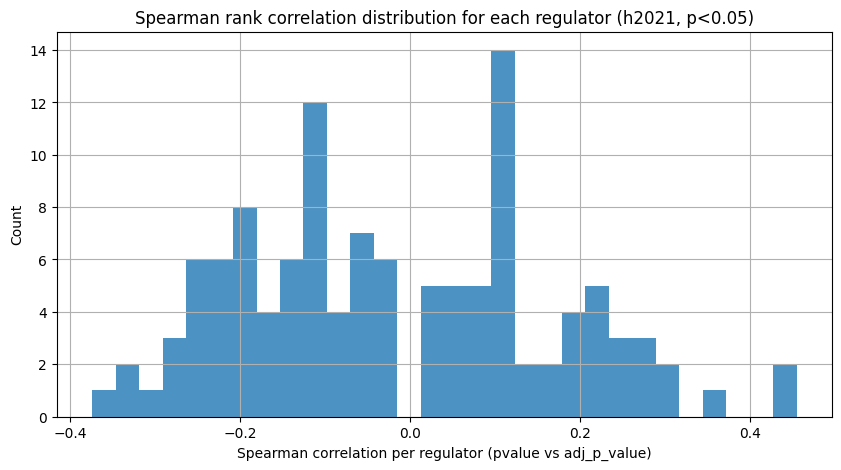

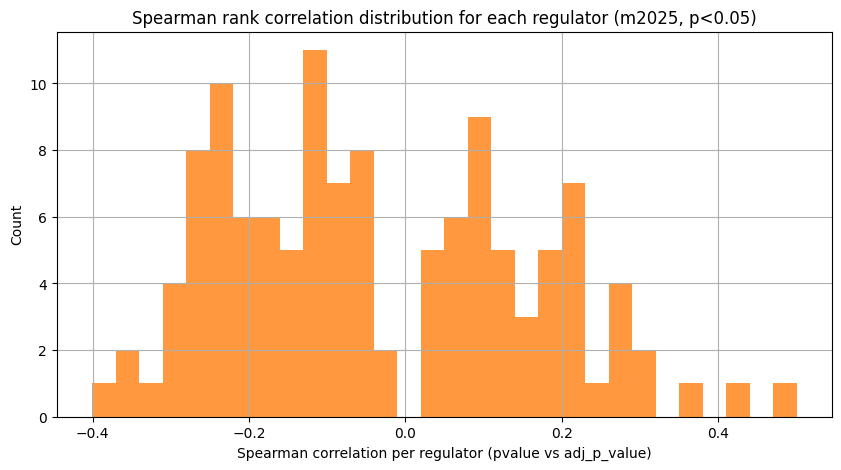

In [98]:
# Group by regulator_symbol, calculate the Spearman rank correlation between 'pvalue' (from harbison_2004) and 'input_vs_target_adj_p_value' (from mahendrawada_2025) for each regulator.
# Visualize the distribution of per-regulator Spearman correlations as separate plots for h2021 and m2025.
# When plotting, only include results for regulators where the correlation p-value is less than 0.05.

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

# Ensure regulator_symbol, pvalue, and input_vs_target_adj_p_value columns exist for h2021
assert 'regulator_symbol' in harbison_h2021_joined.columns
assert 'pvalue' in harbison_h2021_joined.columns
assert 'input_vs_target_adj_p_value' in harbison_h2021_joined.columns

# Likewise, ensure required columns exist for m2025
assert 'regulator_symbol' in harbison_m2025_joined.columns
assert 'pvalue' in harbison_m2025_joined.columns
assert 'input_vs_target_adj_p_value' in harbison_m2025_joined.columns

def groupwise_spearman(df, p_col, q_col, group_col='regulator_symbol', min_size=3, pval_threshold=0.05):
    """
    Calculates per-group Spearman correlation and filters by minimum group size and p-value threshold.
    """
    results = []
    for reg, group in df.groupby(group_col):
        g_clean = group[[p_col, q_col]].dropna()
        if len(g_clean) >= min_size:
            corr, pval = spearmanr(g_clean[p_col], g_clean[q_col])
            if pd.notna(corr) and pd.notna(pval) and pval < pval_threshold:
                results.append(
                    {
                        "regulator": reg,
                        "spearman_corr": corr,
                        "spearman_pval": pval,
                        "n": len(g_clean)
                    }
                )
    return pd.DataFrame(results)

# For the h2021 dataset
h2021_corrs = groupwise_spearman(
    harbison_h2021_joined,
    "pvalue",
    "input_vs_target_adj_p_value",
    group_col="regulator_symbol",
    min_size=3,
    pval_threshold=0.05
)

# For the m2025 dataset
m2025_corrs = groupwise_spearman(
    harbison_m2025_joined,
    "pvalue",
    "input_vs_target_adj_p_value",
    group_col="regulator_symbol",
    min_size=3,
    pval_threshold=0.05
)

# Plot the distribution for h2021
plt.figure(figsize=(10, 5))
plt.hist(h2021_corrs['spearman_corr'].dropna(), bins=30, alpha=0.8, color='C0')
plt.xlabel("Spearman correlation per regulator (pvalue vs adj_p_value)")
plt.ylabel("Count")
plt.title("Spearman rank correlation distribution for each regulator (h2021, p<0.05)")
plt.grid(True)
plt.show()

# Plot the distribution for m2025
plt.figure(figsize=(10, 5))
plt.hist(m2025_corrs['spearman_corr'].dropna(), bins=30, alpha=0.8, color='C1')
plt.xlabel("Spearman correlation per regulator (pvalue vs adj_p_value)")
plt.ylabel("Count")
plt.title("Spearman rank correlation distribution for each regulator (m2025, p<0.05)")
plt.grid(True)
plt.show()


In [99]:
# Print the names of regulators with Spearman correlation greater than 0.4 (for h2021 and m2025, p<0.05)

print("Regulators in h2021 with Spearman correlation > 0.4:")
regulators_h2021 = h2021_corrs.loc[h2021_corrs['spearman_corr'] > 0.4, 'regulator']
print(regulators_h2021.tolist())

print("\nRegulators in m2025 (p<0.05) with Spearman correlation > 0.4:")
regulators_m2025 = m2025_corrs.loc[m2025_corrs['spearman_corr'] > 0.4, 'regulator']
print(regulators_m2025.tolist())


Regulators in h2021 with Spearman correlation > 0.4:
['INO4', 'RAP1']

Regulators in m2025 (p<0.05) with Spearman correlation > 0.4:
['INO4', 'RAP1']


# Group by regulators: effect correlation analysis

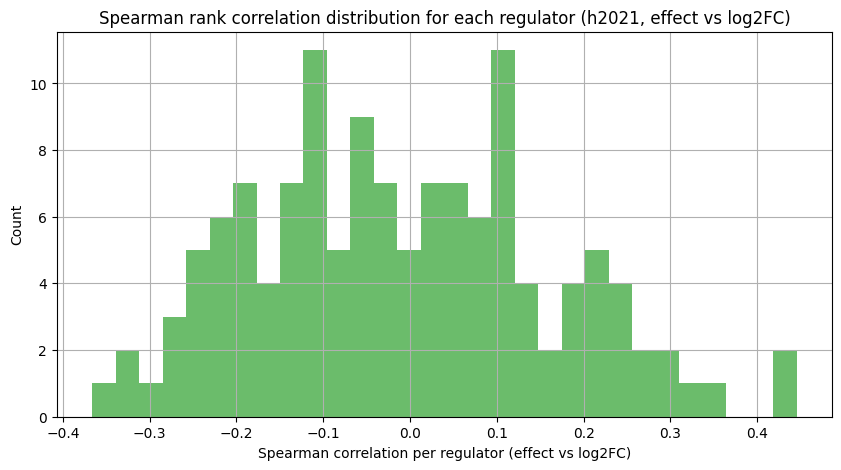

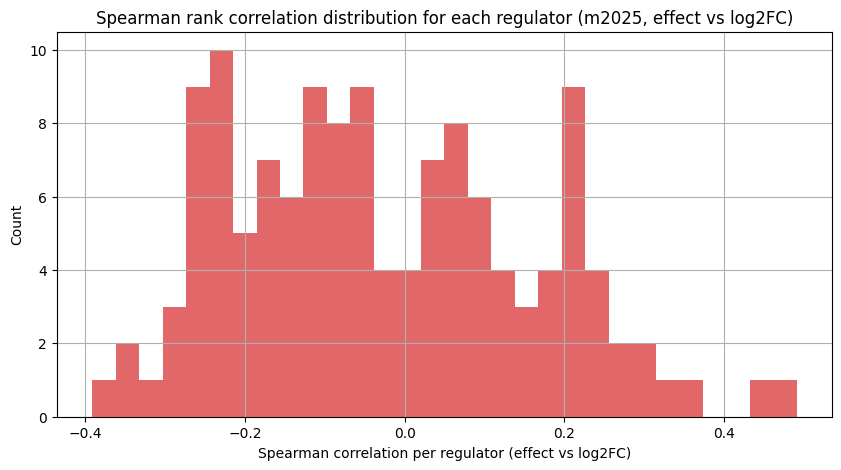

In [100]:
# Group by regulator_symbol, calculate the Spearman correlation between effect and input_vs_target_log2_fold_change
# Perform grouping and plotting for both h2021 and m2025 datasets

from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def groupwise_effect_corr(df, effect_col="effect", logfc_col="input_vs_target_log2_fold_change", group_col="regulator_symbol", min_size=3):
    # Calculate the Spearman correlation coefficient and p-value for each group
    results = []
    grouped = df[[group_col, effect_col, logfc_col]].dropna().groupby(group_col)
    for name, grp in grouped:
        if len(grp) >= min_size:
            corr, pval = spearmanr(grp[effect_col], grp[logfc_col])
            results.append({
                group_col: name,
                "n": len(grp),
                "spearman_corr": corr,
                "pval": pval
            })
    return pd.DataFrame(results)

# Calculate correlations for h2021 dataset
h2021_effect_corrs = groupwise_effect_corr(harbison_h2021_joined)

# Calculate correlations for m2025 dataset
m2025_effect_corrs = groupwise_effect_corr(harbison_m2025_joined)

# Plot histogram for h2021
plt.figure(figsize=(10, 5))
plt.hist(h2021_effect_corrs['spearman_corr'].dropna(), bins=30, alpha=0.7, color='C2', label="h2021")
plt.xlabel("Spearman correlation per regulator (effect vs log2FC)")
plt.ylabel("Count")
plt.title("Spearman rank correlation distribution for each regulator (h2021, effect vs log2FC)")
plt.grid(True)
plt.show()

# Plot histogram for m2025
plt.figure(figsize=(10, 5))
plt.hist(m2025_effect_corrs['spearman_corr'].dropna(), bins=30, alpha=0.7, color='C3', label="m2025")
plt.xlabel("Spearman correlation per regulator (effect vs log2FC)")
plt.ylabel("Count")
plt.title("Spearman rank correlation distribution for each regulator (m2025, effect vs log2FC)")
plt.grid(True)
plt.show()


In [101]:
# Print regulators with Spearman correlation > 0.4 for h2021 and m2025

# For h2021
high_corr_h2021 = h2021_effect_corrs[h2021_effect_corrs['spearman_corr'] > 0.4]
print("Regulators with Spearman correlation > 0.4 (h2021):")
print(high_corr_h2021['regulator_symbol'].tolist())

# For m2025
high_corr_m2025 = m2025_effect_corrs[m2025_effect_corrs['spearman_corr'] > 0.4]
print("Regulators with Spearman correlation > 0.4 (m2025):")
print(high_corr_m2025['regulator_symbol'].tolist())


Regulators with Spearman correlation > 0.4 (h2021):
['INO4', 'RAP1']
Regulators with Spearman correlation > 0.4 (m2025):
['INO4', 'RAP1']


# Group by regulators: effect vs p-value correlation analysis

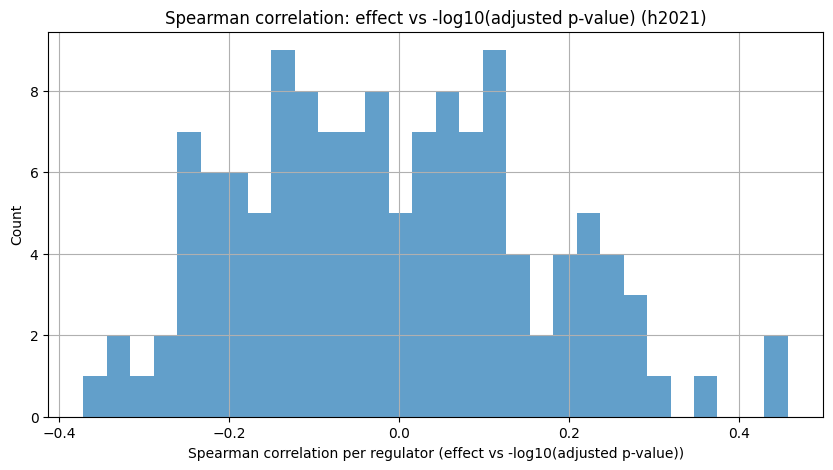

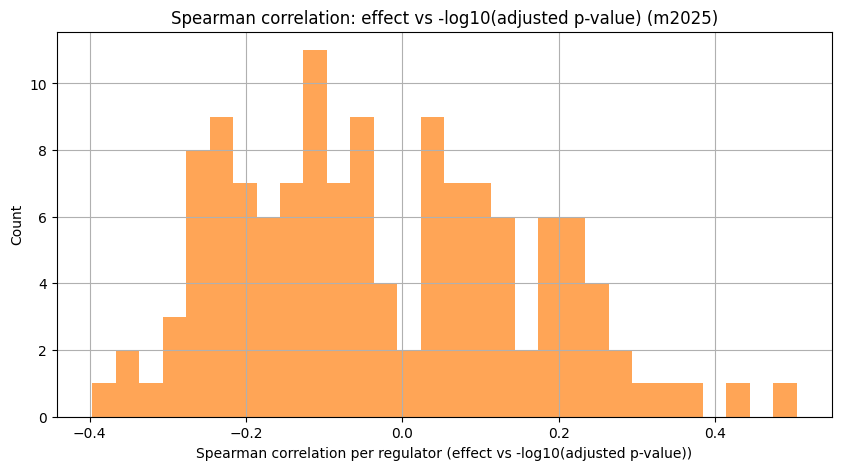

In [102]:
import numpy as np

def groupwise_effect_pvalue_corr(df):
    """
    For each regulator_symbol, compute Spearman's rank correlation between effect and -log10(p-value)
    """
    from scipy.stats import spearmanr

    results = []
    grouped = df.groupby('regulator_symbol')
    for reg, group in grouped:
        # Drop missing values
        valid = group[['effect', 'input_vs_target_adj_p_value']].dropna()
        if len(valid) < 2:
            corr = np.nan
        else:
            # Use -log10(p-value) to emphasize stronger significance
            neglog_p = -np.log10(valid['input_vs_target_adj_p_value'].replace(0, np.nan))
            # Sometimes there might still be nans or infs after log transformation
            mask = neglog_p.replace([np.inf, -np.inf], np.nan).notnull() & valid['effect'].notnull()
            if mask.sum() < 2:
                corr = np.nan
            else:
                corr, _ = spearmanr(valid['effect'][mask], neglog_p[mask])
        results.append({"regulator_symbol": reg, "spearman_corr": corr, "n": len(valid)})
    return pd.DataFrame(results)

# Calculate groupwise effect vs -log10(adj p-value) correlation for h2021 and m2025
h2021_effect_p_corrs = groupwise_effect_pvalue_corr(harbison_h2021_joined)
m2025_effect_p_corrs = groupwise_effect_pvalue_corr(harbison_m2025_joined)

# Plotting
plt.figure(figsize=(10, 5))
plt.hist(h2021_effect_p_corrs['spearman_corr'].dropna(), bins=30, alpha=0.7, color='C0')
plt.xlabel("Spearman correlation per regulator (effect vs -log10(adjusted p-value))")
plt.ylabel("Count")
plt.title("Spearman correlation: effect vs -log10(adjusted p-value) (h2021)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(m2025_effect_p_corrs['spearman_corr'].dropna(), bins=30, alpha=0.7, color='C1')
plt.xlabel("Spearman correlation per regulator (effect vs -log10(adjusted p-value))")
plt.ylabel("Count")
plt.title("Spearman correlation: effect vs -log10(adjusted p-value) (m2025)")
plt.grid(True)
plt.show()


In [103]:
print("h2021 regulators with Spearman correlation > 0.4:")
print(h2021_effect_p_corrs[h2021_effect_p_corrs['spearman_corr'] > 0.4]['regulator_symbol'].tolist())

print("\nm2025 regulators with Spearman correlation > 0.4:")
print(m2025_effect_p_corrs[m2025_effect_p_corrs['spearman_corr'] > 0.4]['regulator_symbol'].tolist())


h2021 regulators with Spearman correlation > 0.4:
['INO4', 'RAP1']

m2025 regulators with Spearman correlation > 0.4:
['INO4', 'RAP1']
